In [1]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IPL_PROJECT/batting_stats.csv'
batting_stats = pd.read_csv(file_path)


Mounted at /content/drive


# **IMPACT PLAYERS**

Question: Who are the most impactful batters?

In [22]:
impact_players = batting_stats[
    (batting_stats['runs'] > 2000) &
    (batting_stats['strike_rate'] > 120)
]
impact_players = impact_players.sort_values(
    by='effectiveness_score', ascending=False
).head(10)

impact_players

,batter,runs,balls_faced,strike_rate,effectiveness_score,effectiveness_score_display
0,V Kohli,8671,6453,134.371610,1.165136e+06,"1,165,136"
1,RG Sharma,7048,5277,133.560735,9.413361e+05,"941,336"
2,DA Warner,6567,4604,142.636838,9.366961e+05,"936,696"
3,S Dhawan,6769,5226,129.525450,8.767578e+05,"876,757"
4,AB de Villiers,5181,3355,154.426230,8.000823e+05,"800,082"
5,SK Raina,5536,3977,139.200402,7.706134e+05,"770,613"
6,MS Dhoni,5439,3868,140.615305,7.648066e+05,"764,806"
7,CH Gayle,4997,3267,152.953780,7.643100e+05,"764,310"
8,KL Rahul,5235,3793,138.017400,7.225211e+05,"722,521"
9,KD Karthik,4843,3509,138.016529,6.684140e+05,"668,414"


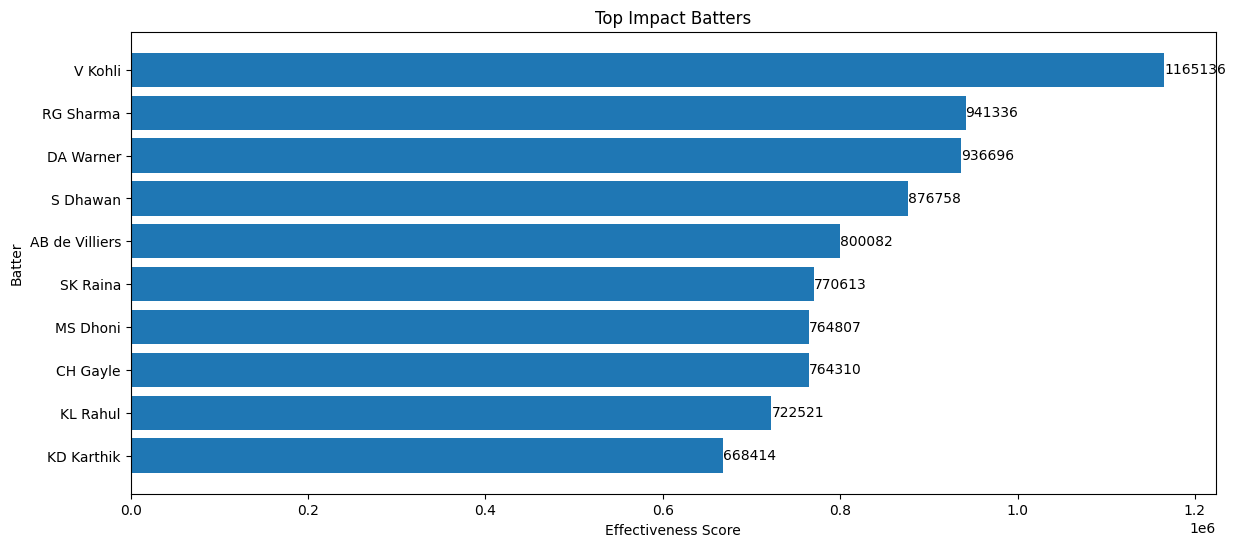

In [33]:
top_players = impact_players.sort_values(by='effectiveness_score', ascending=True).head(10)
plt.figure(figsize=(14, 6))
plt.barh(top_players['batter'] ,top_players['effectiveness_score'])

plt.ylabel('Batter')
plt.title('Top Impact Batters')
plt.xlabel('Effectiveness Score')
for i, v in enumerate(top_players['effectiveness_score']):
    plt.text(v, i, f"{v:.0f}", va='center')

plt.show()

In [2]:
df= pd.read_csv('/content/drive/MyDrive/IPL_PROJECT/IPL_EDA_Base.csv')
df.head()

,match_id,season,date,innings,batting_team,bowling_team,over,ball,batter,bowler,...,toss_decision,player_of_match,winner,win_margin,is_four,is_six,is_boundary,is_dot,is_single,is_wicket
0,335982,2008,2008-04-18,1,KKR,RCB,0,1,SC Ganguly,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,0,1,0
1,335982,2008,2008-04-18,1,KKR,RCB,0,2,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0
2,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,0,1,0
3,335982,2008,2008-04-18,1,KKR,RCB,0,3,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0
4,335982,2008,2008-04-18,1,KKR,RCB,0,4,BB McCullum,P Kumar,...,field,BB McCullum,KKR,140 runs,0,0,0,1,0,0


# **Phase-wise Analysis**

Question: How does the game change across different phases?

In [43]:
# overs are stored as (0-19) 0 indicates first over and 19 indicates last over
def get_phase(over):
    if over <= 5:
        return 'Powerplay'
    elif over <= 14:
        return 'Middle'
    else:
        return 'Death'

df['phase'] = df['over'].apply(get_phase)

## **Runs per over in different phases**

In [45]:
phase_runs = df.groupby('phase')['runs_total'].sum()
phase_balls = df.groupby('phase').size()

run_rate = (phase_runs / phase_balls) * 6
run_rate = run_rate.round(2)
run_rate

,0
phase,
Death,9.52
Middle,7.63
Powerplay,7.66


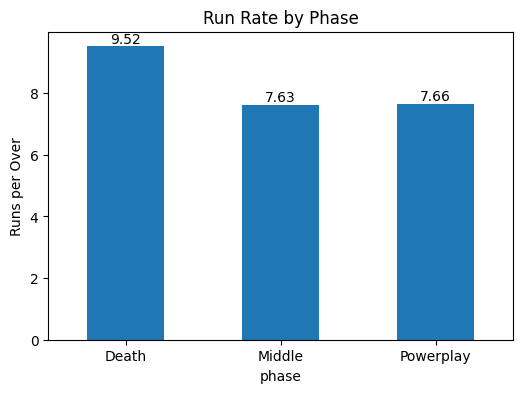

In [47]:
ax = run_rate.plot(kind='bar', figsize=(6,4))

# Add labels
for i, v in enumerate(run_rate):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.title('Run Rate by Phase')
plt.ylabel('Runs per Over')

plt.xticks(rotation=0)
plt.show()

### **Insight:** Run rates increase significantly in the death overs, confirming that teams prioritize aggressive scoring in the final phase, even at the cost of losing wickets

In [52]:
# Total wickets
phase_wickets = df[df['wicket_kind'].notna()].groupby('phase').size()

# Total balls
phase_balls = df.groupby('phase').size()

# Wickets per over
wicket_rate =((phase_wickets / phase_balls) * 6*100)
wicket_rate = wicket_rate.round(2)
wicket_rate

,0
phase,
Death,48.35
Middle,25.15
Powerplay,23.18


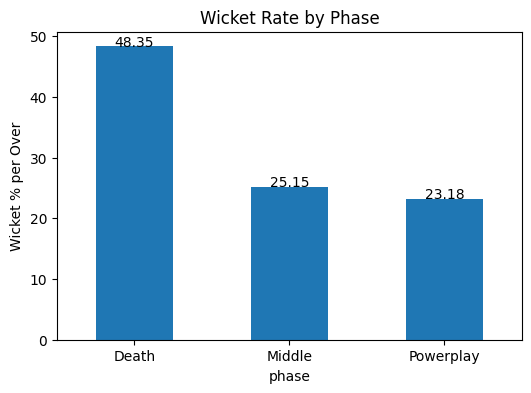

In [54]:
ax = wicket_rate.plot(kind='bar', figsize=(6,4))

# Labels
for i, v in enumerate(wicket_rate):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.title('Wicket Rate by Phase')
plt.ylabel('Wicket % per Over')

plt.xticks(rotation=0)
plt.show()

### **Insight:** Wicket rate analysis reveals that although middle overs see a higher total number of dismissals, the likelihood of losing a wicket per ball increases significantly in the death overs, highlighting the high-risk, high-reward nature of this phase

# **Clutch Performance (ELITE LEVEL)**

Question: Which players perform under pressure?

In [7]:
# =========================================
# STEP 1: Filter ONLY 2nd innings (chasing)
# =========================================

df_chase = df[df['innings'] == 2].copy()


# =========================================
# STEP 2: Get Target (1st innings total)
# =========================================

first_innings_total = df[df['innings'] == 1].groupby('match_id')['runs_total'].sum()

# Map target to 2nd innings
df_chase['target'] = df_chase['match_id'].map(first_innings_total)


# =========================================
# STEP 3: Runs Remaining
# =========================================

df_chase['cum_runs'] = df_chase.groupby('match_id')['runs_total'].cumsum()

df_chase['runs_remaining'] = df_chase['target'] - df_chase['cum_runs']


# =========================================
# STEP 4: Balls Remaining
# =========================================

df_chase['balls_bowled'] = (df_chase['over'] ) * 6 + df_chase['ball']

df_chase['balls_remaining'] = 120 - df_chase['balls_bowled']

# Remove invalid rows (avoid division error)
df_chase = df_chase[df_chase['balls_remaining'] > 0]


# =========================================
# STEP 5: Required Run Rate (RRR)
# =========================================

df_chase['rrr'] = (df_chase['runs_remaining'] / df_chase['balls_remaining']) * 6


# =========================================
# STEP 6: Wickets Remaining
# =========================================

df_chase['is_wicket'] = df_chase['wicket_kind'].notna().astype(int)

df_chase['wickets_fallen'] = df_chase.groupby('match_id')['is_wicket'].cumsum()

df_chase['wickets_remaining'] = 10 - df_chase['wickets_fallen']


# =========================================
# STEP 7: Pressure Index 🔥
# =========================================

df_chase['pressure_index'] = df_chase['rrr'] * (10 / (df_chase['wickets_remaining'] + 1))


# =========================================
# STEP 8: High Pressure Situations
# =========================================

threshold = df_chase['pressure_index'].quantile(0.75)

high_pressure_df = df_chase[df_chase['pressure_index'] >= threshold]


# =========================================
# STEP 9: Batter Performance Under Pressure
# =========================================

clutch_players = high_pressure_df.groupby('batter').agg(
    runs=('runs_batter', 'sum'),
    balls=('batter', 'count')
)

clutch_players['strike_rate'] = (clutch_players['runs'] / clutch_players['balls']) * 100


# =========================================
# STEP 10: Clutch Score 🔥
# =========================================

clutch_players['clutch_score'] = (
    clutch_players['runs'] * clutch_players['strike_rate']
) / 100


# =========================================
# STEP 11: Filter Meaningful Players
# =========================================

clutch_players = clutch_players[
    (clutch_players['runs'] > 200) &
    (clutch_players['balls'] > 100)
]


# =========================================
# STEP 12: Top Clutch Performers
# =========================================

top_clutch = clutch_players.sort_values(by='clutch_score', ascending=False).head(10)

top_clutch

,runs,balls,strike_rate,clutch_score
batter,,,,
MS Dhoni,1350,965,139.896373,1888.601036
KA Pollard,908,645,140.775194,1278.238760
DA Miller,793,512,154.882812,1228.220703
RA Jadeja,864,679,127.245950,1099.405007
AD Russell,702,461,152.277657,1068.989154
AB de Villiers,557,321,173.520249,966.507788
KD Karthik,635,457,138.949672,882.330416
AT Rayudu,562,409,137.408313,772.234719
N Pooran,466,287,162.369338,756.641115


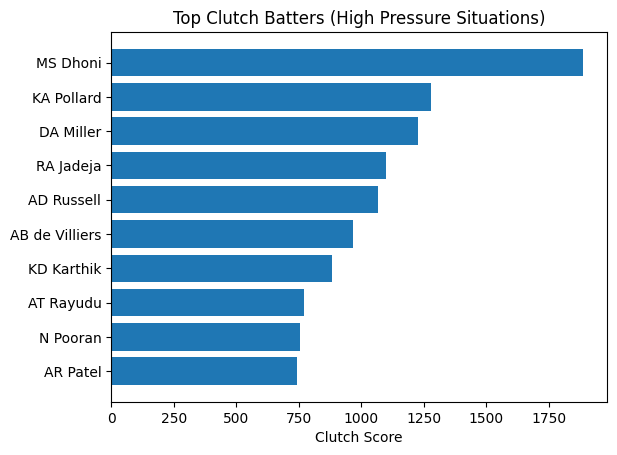

In [8]:

top_plot = top_clutch.iloc[::-1]

plt.barh(top_plot.index, top_plot['clutch_score'])

plt.title('Top Clutch Batters (High Pressure Situations)')
plt.xlabel('Clutch Score')

plt.show()

### **Insight:** Unlike conventional metrics that evaluate performance in isolation, the pressure index integrates match context by accounting for required run rate and wickets in hand. This context-aware approach demonstrates that clutch performance is a distinct skill, as several players with strong overall records do not necessarily excel under high-pressure conditions, emphasizing the importance of situational adaptability in T20 cricket

# **Consistency Score**

Question: Who performs consistently across matches?

In [14]:
import numpy as np
# Match-wise Runs
match_runs = df.groupby(['batter', 'match_id'])['runs_batter'].sum().reset_index()
# Calculate Mean & Std Dev
consistency = match_runs.groupby('batter').agg(
    avg_runs=('runs_batter', 'mean'),
    std_runs=('runs_batter', 'std'),
    matches=('match_id', 'count')
)
# consistency score
consistency['consistency_score'] = (
    consistency['avg_runs'] / (consistency['std_runs'] + 1)
) * np.log(consistency['matches'])
# filter players
consistency = consistency[
    (consistency['matches'] > 30)
]
# Top Consistent Players
top_consistent = consistency.sort_values(
    by='consistency_score', ascending=False
).head(10)

top_consistent

,avg_runs,std_runs,matches,consistency_score
batter,,,,
V Kohli,33.478764,27.355868,259,6.560749
MS Dhoni,22.568465,18.028810,241,6.505054
S Dhawan,30.628959,25.375326,221,6.268742
RA Jadeja,16.804124,13.249803,194,6.212138
DA Warner,35.690217,28.974206,184,6.209412
F du Plessis,32.469388,25.181616,147,6.188934
KL Rahul,38.777778,29.789727,135,6.177893
SK Raina,27.680000,23.215131,200,6.056437
RV Uthappa,25.147208,21.158384,197,5.995826


### **Insight:** Consistency in T20 cricket is not defined by low variation alone, but by the ability to maintain high performance across matches. The refined consistency metric, which normalizes variability and incorporates longevity, reveals that true consistent players are those who combine reliability with sustained scoring impact, rather than merely avoiding fluctuations**

# **FINAL PROJECT SUMMARY**

### This project presents a comprehensive analysis of IPL match data by progressing from basic exploratory analysis to advanced, context-aware metrics. Initial stages focused on understanding overall trends in batting, bowling, match outcomes, and team strategies.

### The analysis was further enhanced by introducing advanced concepts such as phase-wise performance, which revealed the evolving dynamics of T20 matches across powerplay, middle, and death overs.

### A key highlight of the project is the development of a ball-level pressure index, incorporating required run rate and wickets remaining, to identify high-pressure situations during run chases. This enabled a more accurate evaluation of clutch performance, distinguishing players who excel under real match pressure.

### Additionally, consistency analysis was refined by addressing limitations of traditional variability-based metrics, ensuring that high-impact players are not unfairly penalized.

### Overall, the project demonstrates how combining domain knowledge with data analysis techniques can uncover deeper insights into player performance and match strategies, moving beyond conventional statistics to more meaningful, context-driven evaluation.